In [15]:
import numpy as np
from mpi4py import MPI
from basix.ufl import element
from dolfinx import mesh, fem, io, plot
from ufl import TrialFunction, TestFunction, dx

from pylab import meshgrid
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import pyvista
import ufl
from pathlib import Path
from dolfinx.fem.petsc import LinearProblem
from petsc4py import PETSc

from dolfinx import *



### Geometry Source and Boundary Setup

- Discretized domain $\Omega $.
- Function space: Continuous piecewise-linear finite elements $V \subset H^1(\Omega)$.
- Parameters: $D = 1.0$, $\theta = 0.5$, $\Delta t = 0.4$, $t_\text{end} = 40$.
- Constant given velocity field: $\boldsymbol{\beta}(x,y) = (0.5, 0.5)$.

Gaussian source term:
$$
f(x,y) = 10 \exp\!\Big(-\frac{(x-x_0)^2}{2\sigma_x^2}
-\frac{(y-y_0)^2}{2\sigma_y^2}\Big),
$$
with $x_0 = 0.2\,x_\text{lim}$, $y_0 = 0.4\,y_\text{lim}$, $\sigma_x = \sigma_y = 0.02\,x_\text{lim}$.

Boundary condition:
Homogeneous Dirichlet: $u = 0$ on $\partial\Omega$.


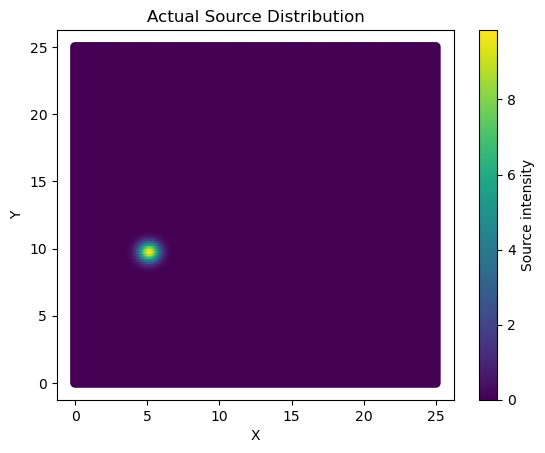

In [16]:
# Create mesh and define function space
y_lim = 25.0
x_lim = 25.0
nx = 128
ny = 128
domain = mesh.create_rectangle(MPI.COMM_WORLD, ((0,0),(x_lim, y_lim)), [nx, ny])
V = fem.functionspace(domain, element("CG", domain.basix_cell(), 1))

# Parameters
D_phys = fem.Constant(domain, 0.1)
theta = fem.Constant(domain, 0.5)
t_end = 40
dt = 0.4

# Velocity field
def velocity_field(x: np.ndarray):
    return np.full((2, x.shape[1]), 0.5)

V_vec = fem.functionspace(domain, ("CG", 1, (domain.geometry.dim,)))
beta = fem.Function(V_vec)
beta.interpolate(velocity_field)

x0, y0 = 0.2 * x_lim, 0.4 * y_lim
sigma_x, sigma_y = 0.02 * x_lim, 0.02 * y_lim  # Standardabweichung

# Source term als 2D-Gauss
def source_term(x: np.ndarray):
    return 10.0 * np.exp(-((x[0] - x0)**2 / (2 * sigma_x**2) + (x[1] - y0)**2 / (2 * sigma_y**2)))

f_true = fem.Function(V)
f_true.interpolate(source_term)

# Boundary condition (zero dirichlet)
def boundary(x):
    return np.isclose(x[0], 0.0) | np.isclose(x[1], 0.0)
    
u_zero = fem.Constant(domain, 0.0)
bc_zero = fem.dirichletbc(u_zero, fem.locate_dofs_geometrical(V, boundary), V)

x_coords = domain.geometry.x[:, 0]
y_coords = domain.geometry.x[:, 1]
f_values = f_true.x.array

plt.figure()
plt.scatter(x_coords, y_coords, c=f_values, cmap='viridis')
plt.colorbar(label='Source intensity')
plt.title('Actual Source Distribution')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

## Forward PDE Variational Formulation

We consider the stationary advection–diffusion equation:

$$
- D \nabla^2 c + \boldsymbol{\beta} \cdot \nabla c = f,
$$

where:
- $D$ is the diffusion coefficient,
- $\boldsymbol{\beta}$ is the velocity field,
- $f$ is the source term.

### Weak Formulation with SUPG Stabilization

The bilinear and linear forms are:

- **Bilinear form**:
  $$
  a(c,v) =
      D\, (\nabla c, \nabla v)
    + (\boldsymbol{\beta} \cdot \nabla c, v)
    + \tau \, (\boldsymbol{\beta} \cdot \nabla c, \boldsymbol{\beta} \cdot \nabla v)
  $$

- **Linear form**:
  $$
  L(v) =
      (f, v)
    + \tau \, (f, \boldsymbol{\beta} \cdot \nabla v)
  $$

Here, $\tau$ denotes the SUPG stabilization parameter:

$$
\tau = \frac{0.5\,h}{\frac{4}{Pe\,h} + 2\,|\boldsymbol{\beta}|},
$$

where:
- $h$ is the cell diameter,
- $Pe = \frac{|\boldsymbol{\beta}| L}{D}$ is the Péclet number,
- $L$ is the characteristic length.

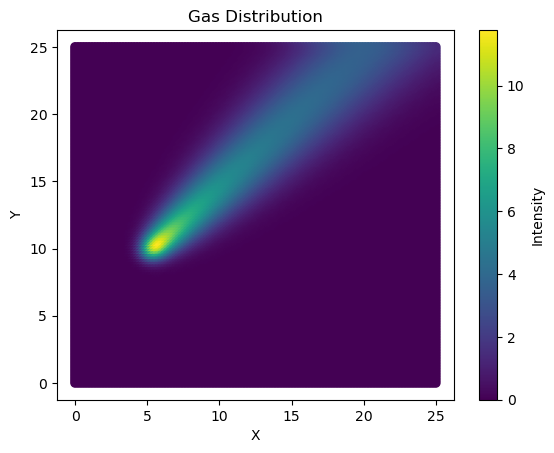

In [17]:
U_char = ufl.sqrt(ufl.dot(beta, beta))
L_char = fem.Constant(domain, x_lim)
h = ufl.CellDiameter(domain)
Pe = U_char * L_char / D_phys
nb = ufl.sqrt(ufl.inner(beta, beta))

tau = 0.5 * h * pow(4.0 / (Pe*h) + 2.0 * nb, -1.0)

v = TestFunction(V)
u = TrialFunction(V)
f = fem.Function(V)

# For true solution: set f to the value of the true source
f = f_true

# a = D_phys * ufl.inner(ufl.grad(u), ufl.grad(v)) * dx + ufl.inner(beta, ufl.grad(u)) * v * dx
# L = f_true * v * dx

# SUPG version
a = D_phys * ufl.inner(ufl.grad(u), ufl.grad(v)) * dx + ufl.inner(beta, ufl.grad(u)) * v * dx + \
         tau * ufl.inner(beta, ufl.grad(u)) * ufl.inner(beta, ufl.grad(v)) * dx
L = f * v * dx + tau * f * ufl.inner(beta, ufl.grad(v)) * dx

forward_problem = LinearProblem(a, L, [bc_zero])

c = forward_problem.solve()
c_values = c.x.array

plt.figure()
plt.scatter(x_coords, y_coords, c=c_values, cmap='viridis')
plt.colorbar(label='Intensity')
plt.title('Gas Distribution')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()



## Inverse Problem Formulation

After the forward problem reaches a steady state ($\frac{\partial c}{\partial t} = 0$), the PDE reads:

$$
\boldsymbol{\beta} \cdot \nabla c - D \nabla^2 c = f,
$$

which can be discretized in FEM form as:

$$
A c = f,
$$

where $A \in \mathbb{R}^{n\times n}$ is the system matrix, and $c, f \in \mathbb{R}^n$.

### Observations and Selection Matrix

We only have measurements $m \in \mathbb{R}^p$ at $p \ll n$ locations.  
Define the selection matrix $M \in \mathbb{R}^{p \times n}$ such that:

$$
M c = m
$$

represents the measured concentration values. Then the inverse problem can be expressed as:

$$
M A^{-1} f = m.
$$

### Minimization Formulation

We formulate an optimization problem to recover $f$:

$$
\begin{aligned}
\min_{f} \quad & J(f) = \frac{1}{2} \| M c(f) - m \|_2^2 \\
\text{s.t.} \quad & A c = f,
\end{aligned}
$$

and the associated Lagrangian:

$$
\mathcal{L}(c, f, \lambda) = J(c) + \lambda^\top (A c - f),
$$

where $\lambda$ is the adjoint (Lagrange multiplier) vector.

---

### KKT Conditions and Weak Form Interpretation

1. **State equation (forward problem)**:
   $$
   \frac{\partial \mathcal{L}}{\partial \lambda} = 0 \quad \Rightarrow \quad A c = f
   $$
   In the continuous weak form, this corresponds to the forward SUPG problem:

   $$
   a(c, v) = L(v) \quad \forall v \in V
   $$

2. **Adjoint equation**:
   $$
   \frac{\partial \mathcal{L}}{\partial c} = 0 \quad \Rightarrow \quad A^\top \lambda = - M^\top (M c - m)
   $$
   In weak form, the adjoint bilinear and linear forms are:

   $$
   a^*(\lambda, v) := a(v, \lambda) = \int_\Omega D \nabla v \cdot \nabla \lambda + (\boldsymbol{\beta} \cdot \nabla v) \lambda \, dx
   $$

   $$
   L^*(v) := - (M^\top (M c - m), v)
   $$

   **Note:** Only the operator is adjointed (trial and test functions swapped).  
   - The **diffusion term is self-adjoint**, so it stays symmetric.  
   - The **convection term is not self-adjoint**, which is why the trial and test functions get swapped in this term.  
   - The right-hand side remains unchanged because it is already linear in the test function.

3. **Gradient w.r.t. source $f$**:
   $$
   \frac{\partial \mathcal{L}}{\partial f} = -\lambda = 0 \quad \Rightarrow \quad f \leftarrow f + \alpha \lambda
   $$
   I. e. we perform the update in the direction of negative gradient (greatest descent):

---

### Solution Algorithm (Pseudo-code)

1. Initialize $f_0$.
2. **Forward solve**: Find $c \in V$ such that $a(c,v) = L(v)$.
3. **Compute residual**: $r = M c - m$.
4. **Adjoint solve**: Find $\lambda \in V$ such that $a^*(\lambda, v) = L^*(v)$.
5. **Update source**: $f \leftarrow f - \alpha \lambda$.
6. Repeat steps 2–5 until convergence.

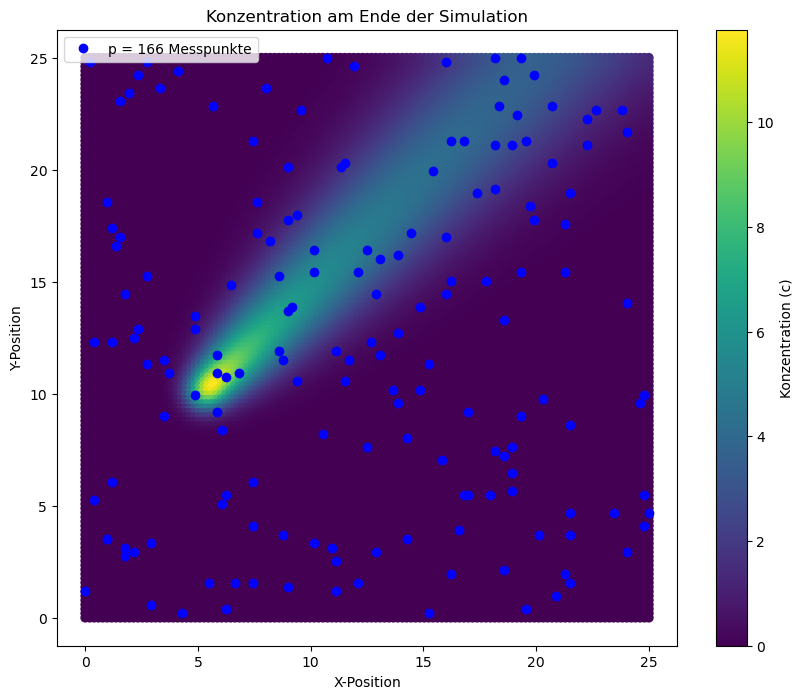

In [18]:
# Select values from c in m
n = len(c_values)
n_measurements = int(0.01 * n)

# random distribution
m_ids = np.random.randint(0, n+1, size=n_measurements) # random distribution

# # evenly spaced distribution
# sqrt_points = int(np.sqrt(n_measurements))
# x_plot = np.linspace(0, x_lim, sqrt_points)
# y_plot = np.linspace(0, y_lim, sqrt_points)
# xx_plot, yy_plot = np.meshgrid(x_plot, y_plot)

# measurement_points = np.vstack([xx_plot.flatten(), yy_plot.flatten()]).T
# mesh_coords = domain.geometry.x[:, :2] 

# m_ids = []
# for point in measurement_points:
#     distances = np.linalg.norm(mesh_coords - point, axis=1)
#     closest_node_index = np.argmin(distances)
#     m_ids.append(closest_node_index)

m = c_values[m_ids]

plt.figure(figsize=(10, 8))
plt.scatter(x_coords, y_coords, c=c_values, cmap='viridis')
plt.plot(x_coords[m_ids], y_coords[m_ids], 'bo', label=f'p = {n_measurements} Messpunkte')
plt.colorbar(label='Konzentration (c)')
plt.title('Konzentration am Ende der Simulation')
plt.xlabel('X-Position')
plt.ylabel('Y-Position')
plt.legend()
plt.show()




In [19]:
# Formulate the adjoint problem with SUPG terms
lagrange_mult = TrialFunction(V)
residual = fem.Function(V)
residual.x.array[:] = 0.0

a_adj = D_phys * ufl.inner(ufl.grad(v), ufl.grad(lagrange_mult)) * dx \
        + ufl.inner(beta, ufl.grad(v)) * lagrange_mult * dx \
        + tau * ufl.inner(beta, ufl.grad(v)) * ufl.inner(beta, ufl.grad(lagrange_mult)) * dx
L_adj = ufl.inner(residual, v) * dx \
        + tau * ufl.inner(beta, ufl.grad(v)) * residual * dx

adjoint_problem = LinearProblem(a_adj, L_adj, [bc_zero])

it   0 mis=4.170e+02 ||grad||=5.957e+01
it  10 mis=6.422e+01 ||grad||=1.294e+01
it  20 mis=5.719e+01 ||grad||=1.266e+01
it  30 mis=5.328e+01 ||grad||=1.263e+01
it  40 mis=5.014e+01 ||grad||=1.262e+01
it  50 mis=4.755e+01 ||grad||=1.260e+01
it  60 mis=4.533e+01 ||grad||=1.258e+01
it  70 mis=4.344e+01 ||grad||=1.261e+01
it  80 mis=4.158e+01 ||grad||=1.257e+01
it  90 mis=4.081e+01 ||grad||=1.255e+01
it 100 mis=4.008e+01 ||grad||=1.256e+01
it 110 mis=3.939e+01 ||grad||=1.257e+01
it 120 mis=3.874e+01 ||grad||=1.255e+01
it 130 mis=3.812e+01 ||grad||=1.256e+01
it 140 mis=3.753e+01 ||grad||=1.256e+01
it 150 mis=3.697e+01 ||grad||=1.255e+01
it 160 mis=3.644e+01 ||grad||=1.258e+01
it 170 mis=3.594e+01 ||grad||=1.256e+01
it 180 mis=3.545e+01 ||grad||=1.257e+01
it 190 mis=3.499e+01 ||grad||=1.256e+01
it 199 mis=3.459e+01 ||grad||=1.257e+01


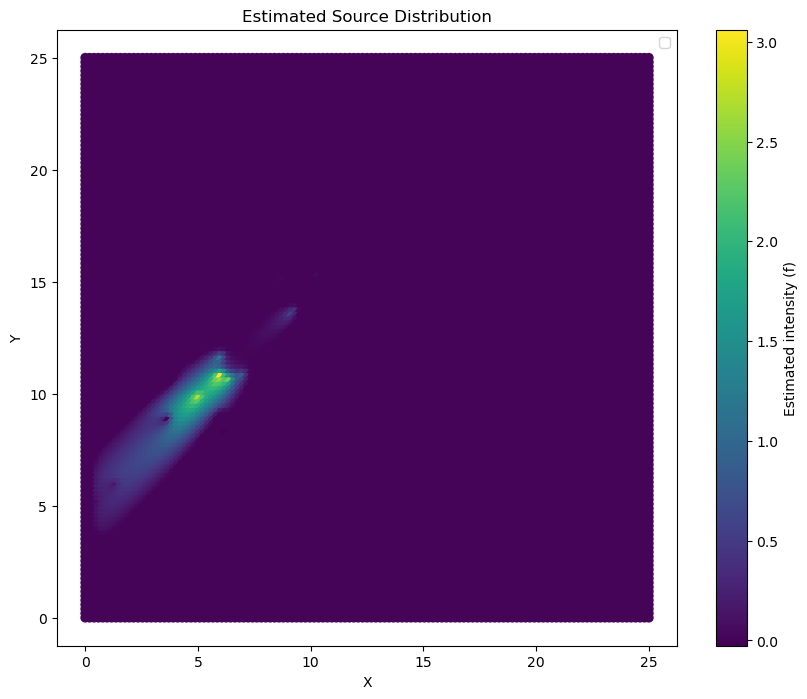

[0.25, 0.0625, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.015625, 0.015625, 0.015625, 0.015625, 0.015625, 0.015625, 0.015625, 0.015625, 0.015625, 0.015625, 0.015625, 0.015625]


In [ ]:
m = c_values[m_ids]
f.x.array[:] = 0.0

max_it = 200
gamma = 1e-3
alpha0 = 1.0
tol_rel = 1e-6
tol_grad = 1e-8
min_iters = 5
c_arm = 1e-4
rho = 0.5
alpha_hist = []
misfit_hist = []

def compute_misfit(c_func: fem.Function, f_func: fem.Function):
    res = c_func.x.array[m_ids] - m
    return 0.5 * np.dot(res, res) + 0.5 * gamma * np.dot(f_func.x.array, f_func.x.array)

for it in range(max_it):
    # forward
    c = forward_problem.solve()

    # Current misfit
    mis = compute_misfit(c, f)

    # Set adjoint rhs setzen und lösen
    residual.x.array[:] = 0.0
    residual.x.array[m_ids] = -(c.x.array[m_ids] - m)
    adj = adjoint_problem.solve()

    # Gradient: gradJ = -adj + gamma * f
    gradJ = -adj.x.array + gamma * f.x.array
    grad_norm = np.linalg.norm(gradJ)

    alpha = alpha0
    f_old = f.x.array.copy()

    # Armijo serach
    while True:
        f.x.array[:] = f_old - alpha * gradJ
        c_trial = forward_problem.solve()
        mis_trial = compute_misfit(c_trial, f)

        if mis_trial <= mis - c_arm * alpha * grad_norm**2:
            break
        alpha *= rho
        if alpha < 1e-14:
            print("Alpha too small.")
            break
    
    mis_new = compute_misfit(c_trial, f)
    misfit_hist.append(mis_new)
    alpha_hist.append(alpha)

    if it % 10 == 0 or it == max_it-1:
        print(f"it {it:3d} mis={mis:.3e} ||grad||={grad_norm:.3e}")

    # Convergence
    if it > 1:
        rel_change = abs(misfit_hist[-2] - misfit_hist[-1]) / max(1e-12, misfit_hist[-2])
        if rel_change < tol_rel or grad_norm < tol_grad:
            print(f"Stopped at it {it}, rel. change={rel_change:.3e}")
            break

plt.figure(figsize=(10, 8))
plt.scatter(x_coords, y_coords, c=f.x.array, cmap='viridis')
plt.colorbar(label='Estimated intensity (f)')
plt.title('Estimated Source Distribution')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

print(alpha_hist[0::10])
